<a href="https://colab.research.google.com/github/psarya/Predictive-Analytics-Lab-Exam-2/blob/main/Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Feature1  Feature2 Target
0    1.7250       520    Yes
1    1.8875       428     No
2    1.6000       552    Yes
3    1.4250       500     No
4    1.7750       628     No
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  1020 non-null   float64
 1   Feature2  1020 non-null   int64  
 2   Target    1000 non-null   object 
dtypes: float64(1), int64(1), object(1)
memory usage: 24.0+ KB
None
           Feature1     Feature2
count   1020.000000  1020.000000
mean      11.436679   520.988235
std      313.061049    69.793442
min        1.250000   400.000000
25%        1.450000   464.000000
50%        1.637500   520.000000
75%        1.828125   584.000000
max    10000.000000   640.000000
Feature1     0
Feature2     0
Target      20
dtype: int64


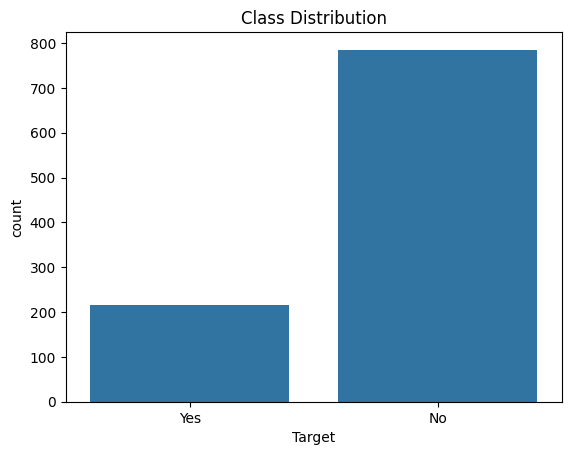

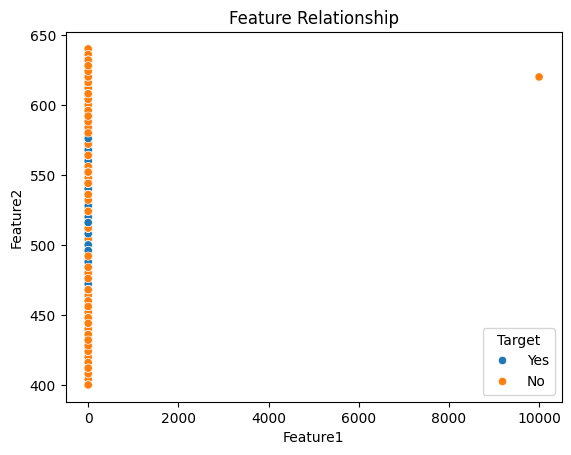

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
data = pd.read_csv("/content/Lab_Exam_binary_classification_dataset (1).csv")

# Basic info
print(data.head())
print(data.info())
print(data.describe())

# Check missing values
print(data.isnull().sum())

# Class distribution
sns.countplot(x='Target', data=data)
plt.title("Class Distribution")
plt.show()

# Scatter plot
sns.scatterplot(x='Feature1', y='Feature2', hue='Target', data=data)
plt.title("Feature Relationship")
plt.show()

In [ ]:
# Remove missing target rows
data = data.dropna(subset=['Target'])

In [ ]:
# Remove extreme outliers
data = data[data['Feature1'] < 5]

In [ ]:
data['Target'] = data['Target'].map({'No': 0, 'Yes': 1})

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = data[['Feature1', 'Feature2']]
y = data['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8
[[160   0]
 [ 40   0]]
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       160
           1       0.00      0.00      0.00        40

    accuracy                           0.80       200
   macro avg       0.40      0.50      0.44       200
weighted avg       0.64      0.80      0.71       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#Although the model achieved an accuracy of 77.5%, it is misleading due to class imbalance.
##The recall and F1-score for class 1 are 0, indicating poor model performance.
#Therefore, accuracy alone is not a reliable metric in this case.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Features and target (already cleaned)
X = data[['Feature1', 'Feature2']]
y = data['Target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree
model = DecisionTreeClassifier(max_depth=5, class_weight='balanced')
model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.93

Confusion Matrix:
 [[144  14]
 [  0  42]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.91      0.95       158
           1       0.75      1.00      0.86        42

    accuracy                           0.93       200
   macro avg       0.88      0.96      0.91       200
weighted avg       0.95      0.93      0.93       200



In [ ]:
#A Decision Tree classifier was used for model building.
#The model was trained on the training dataset and tested on unseen data.
#Class weight balancing was applied to handle class imbalance.
#Model performance was evaluated using accuracy, confusion matrix, and classification metrics.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


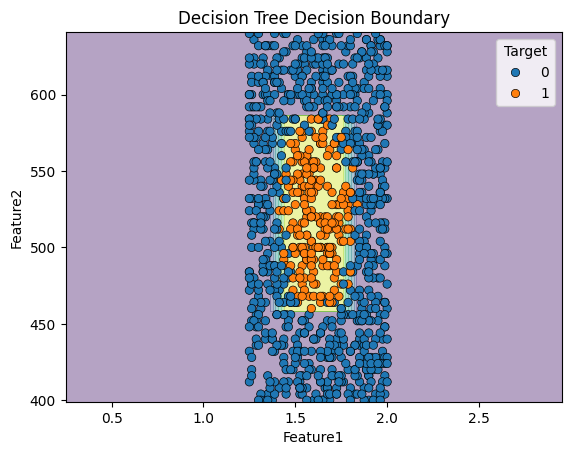

In [ ]:
# Visualize decision boundary
import numpy as np
x_min, x_max = X['Feature1'].min() - 1, X['Feature1'].max() + 1
y_min, y_max = X['Feature2'].min() - 1, X['Feature2'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.4)
sns.scatterplot(x='Feature1', y='Feature2', hue='Target', data=data, edgecolor='k')
plt.title("Decision Tree Decision Boundary")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(X, y, model, title):
    # Set min and max values and give it some padding
    x_min, x_max = X.iloc[:, 0].min() - 0.1, X.iloc[:, 0].max() + 0.1
    y_min, y_max = X.iloc[:, 1].min() - 0.1, X.iloc[:, 1].max() + 0.1
    h = 0.01  # step size in the mesh

    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict the function value for the whole grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the contour and the training examples
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, s=20, edgecolor='k')
    plt.title(title)
    plt.xlabel('Feature1')
    plt.ylabel('Feature2')
    plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


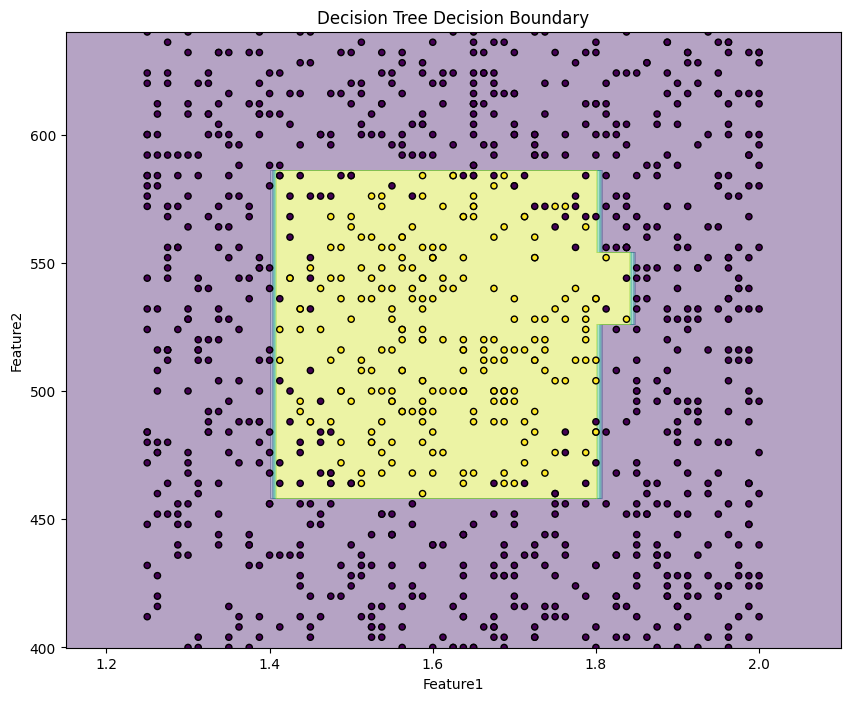

In [ ]:
plot_decision_boundary(X, y, model, "Decision Tree Decision Boundary")